### We can now move to a more complete radiation transport problem including:

- A realistic protoplanetary disk profile
- A star object and stellar irradiation via ray-tracing
- Multiple species (gas and dust)

This assumes you've already checked out ```radiative-tube.ipynb``` and ```radiative-sheet.ipynb``` to familiarize yourself with the code, but there's comments anyway to help out when needed!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u

import pyFLD as fld

In previous problems we assumed a fixed density structure. Here we'll account for changes in the temperature profile by re-calculating the density profile, and iterate between temperature and density updates. Note that dust must account for settling, but in this test we'll turn settling off (for simplicity).

For this problem we'll also only consider the top half of the disk (mirror symmetry), and ignore the inner rim. We therefore will need to provide a (simple) formula for the optical depth between the inner rim and the start of our domain. We'll use the one from Flock+2019:

$$\tau_0(r_\mathrm{min},\theta) \approx \kappa_\star(r_\mathrm{min})\,\rho(r_\mathrm{min},\theta)\left(R_\mathrm{min} - 3R_\star\right)$$

Another thing we need to consider is the dust opacities. We could provide a simple temperature fit, but we can use the fact that ```pyFLD``` can read ```optool```-generated frequency-dependent opacity files and do the frequency averaging internally. Here, we'll use by default gray irradiation, but we'll anyway pass the wavelength information to the star so that the Dust class can build temperature-dependent interpolators for the opacities computed by averaging over the ```optool``` outputs.

In [2]:
d2g = 1e-3 # dust-to-gas ratio

# read the frequency-dependent opacity file
wl, kabs, ksca, g_asy = fld.tools.parse_optool_file('../../examples/opacities/dustkappa_0.1um.inp')

# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, wl=wl) # wavelength info from opacity file
ri   = fld.grid.get_domain_with_ghosts(1, 11, Nx=128, log=True) * u.au # radial direction
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.3, np.pi/2, Nx=64) # polar direction
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1) # azimuthal direction (here quasi-2D)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

debug = False # the debug log helps find issues in your code. It's set to False for now, but you can try switching it to True if curious!

# === initialization of objects ===
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', name='basic', debug=debug)
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='gray', name='basic', debug=debug,
                       kabs_wl=kabs, ksca_wl=ksca, g_wl=g_asy, # passed from the opacity file; otherwise we need to prescribe opacities!
                       grain_rho=2.08*u.g/u.cm**3, grain_size=0*0.1*u.um) # grain size or density = 0 -> no settling

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')

# chosen a posteriori, but doesn't matter much
q = -0.47
H_ = 0.023 * R_ ** ((q+3)/2)
rho = 3e-10 * u.g/u.cm**3 * R_ ** -2.3 * np.exp(-0.5*(z_/H_)**2)

Gas.set_density(np.ones(grid.shape) * rho)
Dust.set_density(np.ones(grid.shape) * rho * d2g)
Gas.set_temperature(np.ones(grid.shape) * 100 * u.K * R_ ** q) # some small starting guess
Dust.set_temperature(np.ones(grid.shape) * 100 * u.K * R_ ** q) # same starting guess

rho_init = 1 * Gas.rho # saving this for later

# === opacities and optical depth ===
# very low gas Rosseland opacity, and some small Planck opacity
Gas.enroll_kappaR(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1e0 * u.cm**2/u.g)
Gas.enroll_kappaPstar(lambda f: 1e0 * u.cm**2/u.g)
# temperature-dependent optool dust opacity for 0.1 um grains from Ziampras+2025 -> ignored since we're reading opacities from optool, but can be activated to overwrite them
# Dust.enroll_kappaR(lambda f: f.tmp.to_value('K')**1.6 * 0.27 * u.cm**2/u.g)
# Dust.enroll_kappaP(lambda f: f.tmp.to_value('K')**1.6 * 0.41 * u.cm**2/u.g)
# Dust.enroll_kappaPstar(lambda f: f.star.T.to_value('K')**1.6 * 0.41 * u.cm**2/u.g)

# τ0 = (ρκ)_{r_in) * (r_in - 3*R_star) from Flock+ (2019)
def get_tau0(fluid): return (fluid.rho * fluid.kappaPstar * (grid.R-3*star.R))[:, :, grid.ibeg]

# inform the fluids
Gas.enroll_tau0(get_tau0) # you can also just pass fld.tools.get_tau0_Flock_2019 here
Dust.enroll_tau0(get_tau0) # and here

# to account for dust settling, we need a vertical turbulence parameter. This can also be a fluid-dependent function!
Dust.enroll_alpha(lambda f: 1e-3)

# === setup ===
Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=False, debug=debug, name='disk', preconditioner='ilu')

# === boundary conditions ===
# for this problem we simplify a bit by only simulating half the disk -> the x2 domain extends to π/2 and is reflective there
bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[0] = fld.tools.T_to_Er(140*u.K)
vals[1] = fld.tools.T_to_Er(40*u.K)
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # the value doesn't matter
Disk.declare_boundaries(bounds, vals)

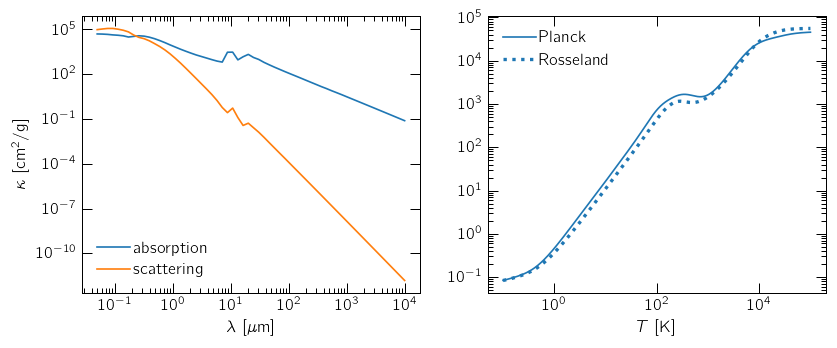

In [3]:
# check that the dust opacities make sense

fig, ax = plt.subplots(ncols=2, dpi=120, figsize=(8,3))

ax[0].plot(wl.to('um'), kabs.to('cm2/g'), label='absorption')
ax[0].plot(wl.to('um'), ksca.to('cm2/g'), label='scattering')

T_opac, kR, kP = fld.tools.compute_mean_opacities(wl=wl, kabs=kabs, ksca=ksca, g=g_asy)

ax[1].plot(T_opac, kP, c='C0', ls='-', label='Planck')
ax[1].plot(T_opac, kR, c='C0', ls=':', lw=2, label='Rosseland')
for axis in ax: axis.legend()
for axis in ax: axis.loglog()
ax[0].set_xlabel(r'$\lambda$ [$\mu$m]')
ax[1].set_xlabel(r'$T$ [K]')
ax[0].set_ylabel(r'$\kappa$ [cm${}^2$/g]')
plt.show()

In [4]:
# run the model to equilibrium. Note that it's not necessary to run until it exits with "0 iterations", but it's fairly quick here.
for i in range(100):
    Disk.advance(dt=1e10 * u.yr)
    if i % 10 == 0: print(f"Cycle {i}: took {Disk.iters} iteration(s).")

Cycle 0: took 19 iteration(s).
Cycle 10: took 22 iteration(s).
Cycle 20: took 17 iteration(s).
Cycle 30: took 13 iteration(s).
Cycle 40: took 5 iteration(s).
Cycle 50: took 6 iteration(s).
Cycle 60: took 1 iteration(s).
Cycle 70: took 0 iteration(s).
Cycle 80: took 0 iteration(s).
Cycle 90: took 0 iteration(s).


In [5]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

#### An analytical solution doesn't always exist, but in the optically thin limit we can expect the gas-dust mixture to approach the temperature given by Chiang & Goldreich (1997):

$$T_\mathrm{thin} = T_\star \left(\frac{\kappa_\star}{\kappa_\mathrm{disk}}\right)^{1/4} \sqrt{\frac{R_\star}{2R}}$$

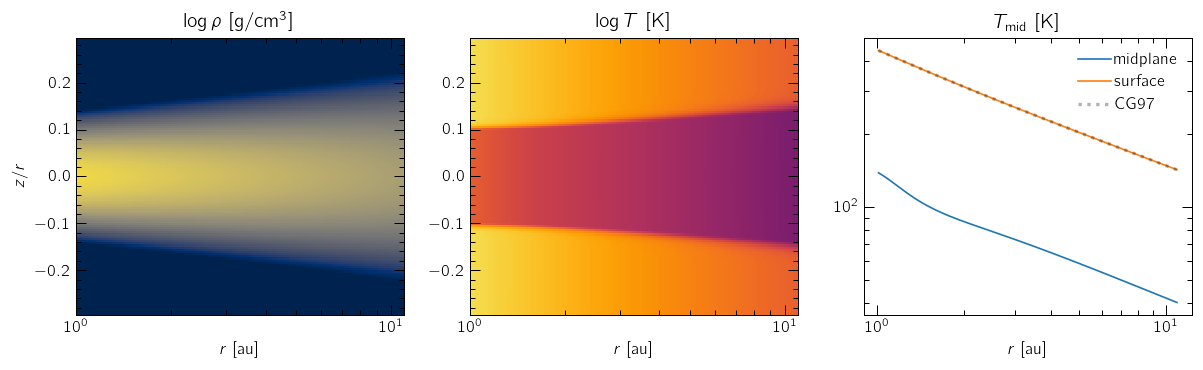

In [6]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 3), dpi=120)

ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-18, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-18, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# the Chiang and Goldreich formula also includes the ratio of opacities at Tstar/Tdisk
opac_factor = fmt((Dust.kappaPstar*Dust.rho+Gas.kappaPstar*Gas.rho)/(Dust.kappaP*Dust.rho+Gas.kappaP*Gas.rho))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')

plt.show()

#### Optionally, we can recompute the gas and dust densities via hydrostatic equilibrium and settling, respectively:

In [7]:
Disk.enforce_hydrostatic_equilibrium()

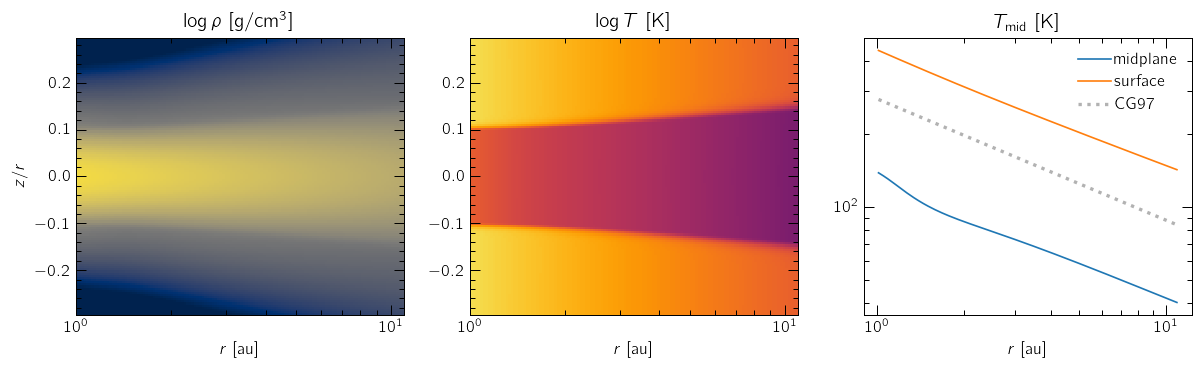

In [8]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 3), dpi=120)

ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-20, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-20, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# note that the Chiang and Goldreich formula now fails because the gas and dust densities have changed!
# To fix this we'd need to re-compute the temperature for this new state.
opac_factor = fmt((Dust.kappaPstar*Dust.rho+Gas.kappaPstar*Gas.rho)/(Dust.kappaP*Dust.rho+Gas.kappaP*Gas.rho))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')

plt.show()

#### The otherwise Gaussian density profile now has wider "wings" at high altitudes due to the increase in temperature:

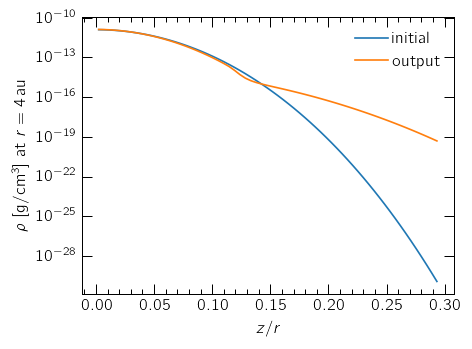

In [9]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

index = np.argmin(np.abs(r-4)) # 4 au

ax.plot(np.cos(theta), fmt(rho_init).to_value('g/cm3')[:,index], label='initial')
ax.plot(np.cos(theta), fmt(Disk.rho).to_value('g/cm3')[:,index], label='output')

ax.set_yscale('log')

ax.legend()
ax.set_xlabel(r'$z/r$')
ax.set_ylabel(r'$\rho$ [g/cm${}^3$] at $r=4$\,au')

plt.show()

#### We can in principle keep iterating between temperature and density updates! Feel free to try this yourself.

In [10]:
# Let's do this again
for i in range(100):
    Disk.advance(dt=1e10 * u.yr)
    if i % 10 == 0: print(f"Cycle {i}: took {Disk.iters} iteration(s).")

Cycle 0: took 20 iteration(s).
Cycle 10: took 8 iteration(s).
Cycle 20: took 7 iteration(s).
Cycle 30: took 1 iteration(s).
Cycle 40: took 1 iteration(s).
Cycle 50: took 0 iteration(s).
Cycle 60: took 0 iteration(s).
Cycle 70: took 0 iteration(s).
Cycle 80: took 0 iteration(s).
Cycle 90: took 0 iteration(s).


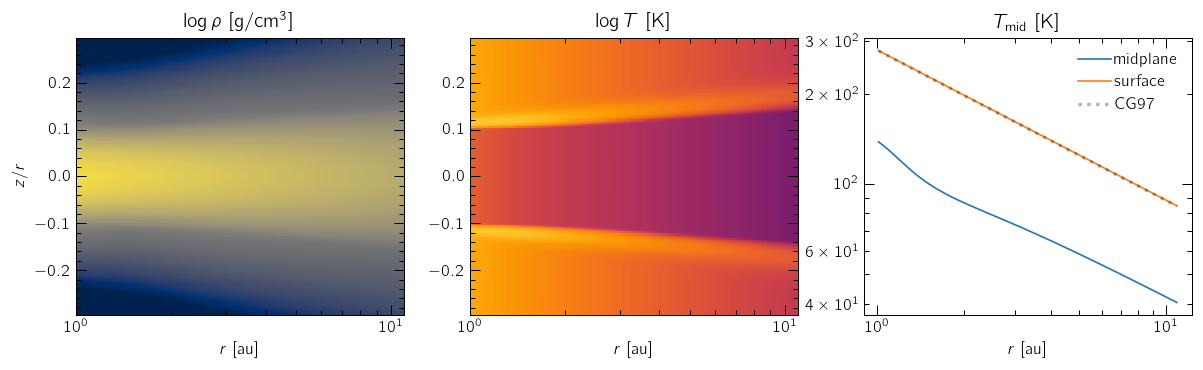

In [11]:
fig, ax = plt.subplots(ncols=3, figsize=(12, 3), dpi=120)

ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-20, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-20, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=2.8)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# note that the Chiang and Goldreich formula now fails because the gas and dust densities have changed!
# To fix this we'd need to re-compute the temperature for this new state.
opac_factor = fmt((Dust.kappaPstar*Dust.rho+Gas.kappaPstar*Gas.rho)/(Dust.kappaP*Dust.rho+Gas.kappaP*Gas.rho))[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')

plt.show()

In [23]:
# export to radmc3d. For this you need to have installed radmc3dPy

import os
dirc = 'radmc/'
if not os.path.exists(dirc): os.mkdir(dirc)

rmc = fld.radmc_helper # a shorthand
# first create a wavelength array that is refined around 10um. This is optional though,
# you can just use star.wl
RMC_wl = rmc.get_wavelength_array(wl_min=wl.min(), wl_max=wl.max(), Npts=wl.size, Tstar=star.T)

# create a RADMC3D-compatible star object from the current star.
# This essentially just adds IO for RADMC3D
RMC_star = rmc.Star(dirc=dirc)
RMC_star.setup_from(Disk.star)
RMC_star.update_wavelengths(RMC_wl) # update with the new wavelength array

# same for the grid, it's the base class + RADMC3D IO
RMC_grid = rmc.Grid(dirc=dirc)
RMC_grid.setup_from(Disk.grid)

# now write the needed fields
rmc.write_wavelength_array(RMC_wl, dirc=dirc) # wavelength_micron.inp
RMC_star.write() # stars.inp
RMC_grid.write() # amr_grid.inp
rmc.write_density_array(rho=[Gas.rho[grid.active], Dust.rho[grid.active]], dirc=dirc) # dust_density.binp
rmc.write_opacity_handle(names=['flat', '0.1um'], dirc=dirc) # dustopac.inp
rmc.write_control_file(dirc=dirc, extra=True, nphot=int(1e6), nphot_scat=int(1e6), scattering_mode_max=1) # radmc3d.inp
# if using a nonzero gas opacity, we also need to write its opacity!
# Currently only supports constant values, and kappaP = kappaPstar
rmc.write_flat_opacities(RMC_wl, Gas.get_kappaP(Gas), dirc=dirc)
_ = os.system(f'cp ../opacities/dustkappa_0.1um.inp {dirc}/') # copy the dust opacities we used above

# we want to make a quick image with RADMC3D (i.e., no "radmc3d mctherm" step) and need temperatures,
# so we can just dump them in RADMC3D format using the pyFLD output:
rmc.write_temperature_array(tmp=[Gas.tmp[grid.active], Dust.tmp[grid.active]], dirc=dirc)

: No grid parameters provided. Created an empty Grid object. Use setup_from() or read_from_file() to set up the grid.


In [14]:
# now move to the radmc/ folder and run:
# radmc3d image lambda 1.25 secondorder npix 256 incl 45 posang -30

In [15]:
# finally, check the image

In [24]:
import radmc3dPy as r3d

def prepare_image(flnm=f'{dirc}/image.out', d=100, mJy=True):
    """reads the radmc3d image and returns its coordinates and fluxes in mJy/px"""
    im = r3d.image.readImage(flnm)

    factor = 1e3 if mJy else 1
    flux = im.imageJyppix[:,:,0] * factor
    flux = np.maximum(flux * d ** -2, 1e-100)
    Nx, Ny = flux.shape

    au = const.au.to_value('cm')
    x = im.x / au / d
    y = im.y / au / d
    return x, y, flux

In [25]:
x, y, flux = prepare_image('radmc/image.out', d=100)

Reading radmc/image.out


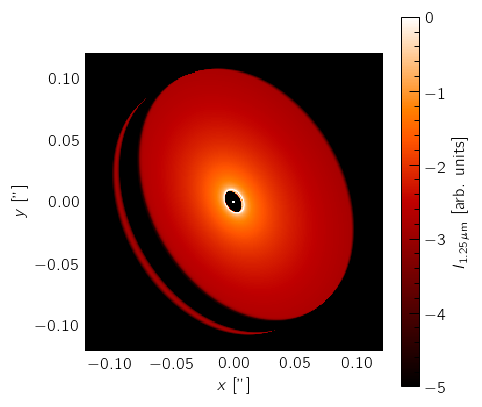

In [27]:
fig, ax = plt.subplots(dpi=120)
ax.set_aspect(1)

img = ax.pcolormesh(x, y, np.log10(flux/flux.mean()), cmap=plt.cm.gist_heat, vmin=-5, vmax=0)
cb = plt.colorbar(img, ax=ax)
cb.set_label(r'$I_{1.25\,\mu\text{m}}$ [arb. units]')

ax.set_xlabel(r"$x$ ['']")
ax.set_ylabel(r"$y$ ['']")
plt.show()